# First FEniCSx computation: diffusion on a two-dimensional domain

We solve one steady diffusion problem and connect each mathematical object to its FEniCSx counterpart. This is a **serial classroom notebook**, using continuous linear triangles. Run cells from top to bottom. Only the plotting helper is hidden; the mesh, coefficient, boundary condition, variational forms, and solve are explicit.

On the nondimensional unit square $\Omega=(0,1)^2$,
\[
-\nabla\cdot(k\nabla u)=f,\qquad u=0\quad\text{on }\partial\Omega,\qquad k(x,y)=1+x.
\]
The positive coefficient varies across the square. We choose the source so that
\[
u_\star=\sin(\pi x)\sin(\pi y),\qquad
f=2\pi^2(1+x)\sin(\pi x)\sin(\pi y)-\pi\cos(\pi x)\sin(\pi y).
\]
Indeed, $-\nabla\cdot(k\nabla u_\star)=-k\Delta u_\star-\partial_xu_\star$. The extra derivative term matters: multiplying the constant-coefficient source by $k$ would be wrong. This manufactured solution tests the discretization; it is not a measured temperature field. The diffusive flux is $\boldsymbol q=-k\nabla u$.

This extends Chapter 6's constant-coefficient example to a genuinely two-dimensional field with variable conductivity. The boundary conditions differ: all four edges are prescribed here.

## Imports and optional plotting helper
FEniCSx implements the finite element operations; UFL represents the weak form. MPI is initialized before importing DOLFINx. The helper below only draws the computed field and writes a PNG; skip its internals during class.

In [1]:
from mpi4py import MPI
from petsc4py import PETSc
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import ufl
import dolfinx
from dolfinx import fem, mesh, io, plot
from dolfinx.fem.petsc import LinearProblem

print("DOLFINx:", dolfinx.__version__)
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

DOLFINx: 0.11.0


In [2]:
def plot_solution(V, u_h, filename):
    # vtk_mesh(V) returns connectivity ordered consistently with V's DOFs.
    cells, cell_types, coordinates = plot.vtk_mesh(V)
    # Each P1 triangle is encoded as [3, vertex0, vertex1, vertex2].
    triangles = cells.reshape(-1, 4)[:, 1:]
    triangulation = mtri.Triangulation(coordinates[:, 0], coordinates[:, 1], triangles)
    fig, ax = plt.subplots(figsize=(6, 5))
    field = ax.tripcolor(triangulation, u_h.x.array.real, shading="gouraud", cmap="viridis")
    ax.triplot(triangulation, color="black", linewidth=0.25, alpha=0.35)
    fig.colorbar(field, ax=ax, label=r"$u_h$")
    ax.set(xlabel="x", ylabel="y", title="P1 diffusion solution", aspect="equal")
    fig.tight_layout()
    fig.savefig(filename, dpi=160)
    plt.show()

## 1. Mesh and approximation space
`N` is the number of subdivisions along each coordinate, not the total number of triangles. Each square is split into two triangles. The scalar P1 space has one degree of freedom per vertex. `COMM_SELF` keeps this first notebook on one process, which also makes plotting straightforward.

In [3]:
N = 16

domain = mesh.create_unit_square(MPI.COMM_SELF, N, N, cell_type=mesh.CellType.triangle)
V = fem.functionspace(domain, ("Lagrange", 1))
print("Triangles:", domain.topology.index_map(2).size_global)
print("Degrees of freedom:", V.dofmap.index_map.size_global)

Triangles: 512
Degrees of freedom: 289


## 2. Coefficient and source
`SpatialCoordinate` supplies the physical coordinates in a symbolic expression. The expressions below are evaluated during quadrature. They are not nodal arrays.

In [4]:
x = ufl.SpatialCoordinate(domain)
k = 1 + x[0]
u_exact = ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])
f = (2 * np.pi**2 * (1 + x[0]) * u_exact
     - np.pi * ufl.cos(np.pi * x[0]) * ufl.sin(np.pi * x[1]))

## 3. Prescribed boundary values
An edge is a facet of a triangular mesh. First locate all exterior edges; then find the finite element degrees of freedom on those edges. The boundary value is zero. We impose it explicitly rather than relying on the source or the plotted solution to suggest a boundary condition.

In [5]:
facet_dim = domain.topology.dim - 1
boundary_facets = mesh.locate_entities_boundary(
    domain, facet_dim, lambda coordinates: np.full(coordinates.shape[1], True)
)
boundary_dofs = fem.locate_dofs_topological(V, facet_dim, boundary_facets)
bc = fem.dirichletbc(PETSc.ScalarType(0.0), boundary_dofs, V)
print("Boundary degrees of freedom:", len(boundary_dofs))

Boundary degrees of freedom: 64


## 4. Variational forms and solve
Define the bilinear and linear forms by
\[
a(u,v)=\int_\Omega k\nabla u\cdot\nabla v\,dx
,\qquad \ell(v)=\int_\Omega fv\,dx.
\]
Find $u\in H^1_0(\Omega)$ such that $a(u,v)=\ell(v)$ for every $v\in H^1_0(\Omega)$. The discrete problem uses the P1 subspace.

There is no boundary integral because the test function vanishes on the entire boundary. `u` below is a trial symbol; `u_h` will hold the computed solution. `LinearProblem` assembles and applies the boundary conditions, then solves the algebraic system. This is the assembly machinery developed explicitly in Chapter 5, now generated from the weak form. A direct LU solver is sufficient for this small demonstration. It is not a scalable solver recommendation.

In [6]:
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
dx = ufl.Measure("dx", domain=domain, metadata={"quadrature_degree": 6})
a = k * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx
L = f * v * dx

problem = LinearProblem(
    a, L, bcs=[bc], petsc_options_prefix="classroom_diffusion_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu",
                   "ksp_error_if_not_converged": True}
)
u_h = problem.solve()
u_h.name = "u"
u_h.x.scatter_forward()
print("Solver convergence reason:", problem.solver.getConvergedReason())

Solver convergence reason: 4


## 5. Inspect the solution
The boundary values should be zero, and the interior should resemble the prescribed smooth reference field. A plausible picture is useful, but it does not establish accuracy.

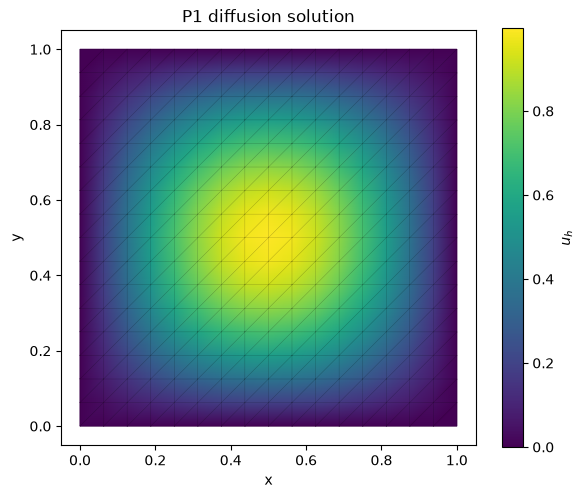

Largest absolute boundary value: 0.0


In [7]:
plot_solution(V, u_h, output_dir / "solution.png")
print("Largest absolute boundary value:", np.max(np.abs(u_h.x.array[boundary_dofs])))

## 6. Measure solution error
We first compare the fields using $\|u_h-u_\star\|_{L^2(\Omega)}$. The expression is integrated over elements; comparing values only at nodes would miss error inside the elements. The analytic field is used directly, not interpolated into the same P1 space.

In [8]:
error = u_h - u_exact
error_L2 = np.sqrt(fem.assemble_scalar(fem.form(ufl.inner(error, error) * dx)).real)
print(f"L2 error: {error_L2:.6e}")

L2 error: 5.353506e-03


## 7. Optional: gradient error and an algebraic consistency check
The energy error is $\left(\int_\Omega k|\nabla(u_h-u_\star)|^2 dx\right)^{1/2}$. Derivatives are more demanding than values. Chapter 7 will explain the rates expected under smoothness and mesh assumptions. For a separate check, take $v=u_h$ in the discrete weak form: the two sides should agree. This identity checks the assembled solve; it does not establish accuracy by itself.

In [9]:
error_energy = np.sqrt(fem.assemble_scalar(
    fem.form(k * ufl.inner(ufl.grad(error), ufl.grad(error)) * dx)).real)
internal = fem.assemble_scalar(fem.form(k * ufl.inner(ufl.grad(u_h), ufl.grad(u_h)) * dx)).real
external = fem.assemble_scalar(fem.form(f * u_h * dx)).real
balance_relative = abs(internal - external) / max(abs(external), 1.0)
print(f"Energy error: {error_energy:.6e}")
print(f"Discrete weak-form balance (relative): {balance_relative:.3e}")

Energy error: 2.664181e-01
Discrete weak-form balance (relative): 7.269e-16


## 8. Export for ParaView
Keep `diffusion.xdmf` and its companion `diffusion.h5` together. The XDMF file describes where the mesh and field data are stored. The companion guide explains how to display this field and its mesh.

In [10]:
with io.XDMFFile(domain.comm, output_dir / "diffusion.xdmf", "w") as file:
    file.write_mesh(domain)
    file.write_function(u_h)
print("Open in ParaView:", (output_dir / "diffusion.xdmf").resolve())

Open in ParaView: /Users/prashant/Dropbox/Work/Simulations/website_related/finite-element-methods/lectures/demos/diffusion_2d/results/diffusion.xdmf


## In-class question and next experiment
Before changing the code, predict what happens to the field if the same source is kept while the conductivity is doubled. For this linear homogeneous-Dirichlet problem, the solution is halved. Treat this as a prediction during class. For an optional test afterward, replace only `k = 1 + x[0]` with `k = 2 * (1 + x[0])`. **Leave `u_exact` and `f` in section 2 unchanged** so the source stays fixed. In section 6 change the error expression to `error = u_h - 0.5 * u_exact`; section 7 uses that same `error`. Restart and run all cells, so the weak form and solver are rebuilt with the new coefficient. Restore both changed lines afterward. Do not halve the definition of `u_exact` in section 2: that would also alter part of the source expression.

For refinement, change `N` to 8, 16, then 32 and restart/run all each time. Record the L2 and energy errors. If an error scales as $h^p$, halving $h$ gives $p=\log_2(E_h/E_{h/2})$. The instructor verification script repeats these same cells; there is no second hidden implementation of the solver.

API reference: [DOLFINx Poisson demonstration](https://docs.fenicsproject.org/dolfinx/main/python/demos/demo_poisson.html). This notebook was designed for the locally tested DOLFINx 0.11.0 environment; check the setup guide before using a different release.